# Quantum-Inspired Evolutionary Algorithm vs Genetic Algorithm
## Benchmarking on the 0/1 Knapsack Problem

This notebook implements and compares two metaheuristic optimizers on the classic **0/1 knapsack problem**:

| Algorithm | Core idea |
|-----------|-----------|
| **Genetic Algorithm (GA)** | Binary chromosomes evolved via tournament selection, two-point crossover, and bit-flip mutation |
| **Quantum-Inspired EA (QIEA)** | Q-bit chromosomes storing probability amplitudes, collapsed to classical solutions each generation and updated via a quantum rotation gate (Han & Kim, 2002) |

**Why this comparison?**  QIEA's proponents claim that a single Q-bit individual implicitly represents a *superposition* of classical solutions, giving superior exploration with a much smaller population. We test that claim under a **controlled experimental protocol** — same instances, same fitness-evaluation budget, same constraint-handling scheme, and 30 independent trials with statistical significance testing.

**What to expect:**  This is an open experiment. QIEA may or may not outperform a well-tuned GA — the point is to find out *when* and *why*, not to confirm a predetermined answer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from dataclasses import dataclass
from typing import Optional
import time
from tqdm.auto import tqdm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global config ──
MASTER_SEED = 42
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
})
print("Environment ready \u2713")

Environment ready ✓


## 2. Problem Definition

We need four things before touching any algorithm:
1. A **KnapsackInstance** data holder
2. A **random instance generator** (reproducible via seed)
3. A **dynamic-programming solver** for ground-truth optimal values
4. A shared **repair + evaluate** pipeline that both algorithms will use identically

### Constraint handling — greedy repair
Instead of a penalty function (which introduces a tuning-sensitive penalty coefficient), we use **greedy repair**: drop included items in ascending order of value/weight ratio until the solution is feasible. This guarantees every evaluated solution is feasible, so fitness values are directly comparable across algorithms.

In [2]:
@dataclass
class KnapsackInstance:
    n_items: int
    weights: np.ndarray
    values: np.ndarray
    capacity: int
    optimal_value: Optional[int] = None
    optimal_solution: Optional[np.ndarray] = None
    seed: int = 0

    def __repr__(self):
        opt = f", optimal={self.optimal_value}" if self.optimal_value else ""
        return f"Knapsack(n={self.n_items}, C={self.capacity}{opt})"


def generate_instance(n, seed=42):
    rng = np.random.RandomState(seed)
    weights = rng.randint(1, 101, size=n)
    values  = rng.randint(1, 101, size=n)
    capacity = int(0.5 * np.sum(weights))
    return KnapsackInstance(n_items=n, weights=weights, values=values,
                            capacity=capacity, seed=seed)


def dp_optimal(instance):
    """Exact 0/1 knapsack via DP.  O(n * C) time."""
    n, C = instance.n_items, instance.capacity
    w, v  = instance.weights.astype(int), instance.values.astype(int)

    dp = np.zeros((n + 1, C + 1), dtype=np.int64)
    for i in range(1, n + 1):
        dp[i, :] = dp[i - 1, :]
        if w[i - 1] <= C:
            caps = np.arange(w[i - 1], C + 1)
            alt  = dp[i - 1, caps - w[i - 1]] + v[i - 1]
            dp[i, caps] = np.maximum(dp[i, caps], alt)

    # backtrack to recover solution
    sol = np.zeros(n, dtype=int)
    c = C
    for i in range(n, 0, -1):
        if dp[i, c] != dp[i - 1, c]:
            sol[i - 1] = 1
            c -= w[i - 1]

    instance.optimal_value    = int(dp[n, C])
    instance.optimal_solution = sol
    return instance.optimal_value


def repair(solution, weights, values, capacity):
    """Greedy repair following the reference implementation (Knapsack_repair.py type=2):
    Phase 1 — drop items with highest weight/value ratio until feasible.
    Phase 2 — greedily add back unselected items (highest v/w ratio first) that still fit.
    """
    sol = solution.copy().astype(int)
    w = weights.astype(float)
    v = values.astype(float)

    # Phase 1: drop worst-ratio items until feasible
    total_w = np.dot(sol, weights)
    if total_w > capacity:
        included = np.where(sol == 1)[0]
        # sort by v/w ascending (worst first) — equivalent to reference's w/p descending
        ratios = v[included] / w[included]
        order  = included[np.argsort(ratios)]
        for idx in order:
            sol[idx] = 0
            total_w -= weights[idx]
            if total_w <= capacity:
                break

    # Phase 2: greedily add back unselected items that fit
    excluded = np.where(sol == 0)[0]
    if len(excluded) > 0:
        ratios_ex = v[excluded] / w[excluded]
        order_ex  = excluded[np.argsort(-ratios_ex)]   # best ratio first
        for idx in order_ex:
            if total_w + weights[idx] <= capacity:
                sol[idx] = 1
                total_w += weights[idx]

    return sol


def evaluate(solution, instance):
    """Repair if needed, return (fitness, repaired_solution)."""
    repaired = repair(solution, instance.weights, instance.values, instance.capacity)
    return int(np.dot(repaired, instance.values)), repaired


print("Problem module loaded \u2713")

Problem module loaded ✓


In [3]:
# ── Quick sanity check ──
test_inst = generate_instance(n=20, seed=99)
opt_val   = dp_optimal(test_inst)
print(f"Test instance: {test_inst}")
print(f"DP optimal value: {opt_val}")
print(f"Optimal solution weight: {np.dot(test_inst.optimal_solution, test_inst.weights)}")

# verify repair on an all-ones (infeasible) solution
all_ones = np.ones(test_inst.n_items, dtype=int)
f, r = evaluate(all_ones, test_inst)
print(f"All-ones repaired fitness: {f}  (weight {np.dot(r, test_inst.weights)} <= {test_inst.capacity})")
assert np.dot(r, test_inst.weights) <= test_inst.capacity, "Repair failed!"
print("Sanity checks passed \u2713")

Test instance: Knapsack(n=20, C=514, optimal=666)
DP optimal value: 666
Optimal solution weight: 507
All-ones repaired fitness: 666  (weight 507 <= 514)
Sanity checks passed ✓


## 3. Genetic Algorithm (GA)

Standard binary-coded GA with:
- **Tournament selection** (k=3) — balances selection pressure and diversity
- **Two-point crossover** (p=0.85) — preserves building blocks better than single-point
- **Bit-flip mutation** (rate = 1/n per bit) — standard adaptive rate
- **Elitism** — best-ever individual replaces the worst child each generation

Population size is set to **50**. Each generation evaluates exactly 50 offspring, so the evaluation budget is consumed in clean increments.

In [4]:
def tournament_select(pop, fits, k, rng):
    idx = rng.randint(0, len(pop), size=k)
    return pop[idx[np.argmax(fits[idx])]].copy()


def two_point_crossover(p1, p2, rng):
    n = len(p1)
    pts = sorted(rng.choice(n, size=2, replace=False))
    c1, c2 = p1.copy(), p2.copy()
    c1[pts[0]:pts[1]] = p2[pts[0]:pts[1]]
    c2[pts[0]:pts[1]] = p1[pts[0]:pts[1]]
    return c1, c2


def bit_flip_mutate(sol, rate, rng):
    mask = rng.random(len(sol)) < rate
    sol[mask] = 1 - sol[mask]
    return sol


def run_ga(instance, pop_size=50, max_evals=10000, crossover_prob=0.85,
           mutation_rate=None, tournament_k=3, seed=0):
    rng = np.random.RandomState(seed)
    n = instance.n_items
    if mutation_rate is None:
        mutation_rate = 1.0 / n

    t0 = time.perf_counter()

    # initialise random population & evaluate
    pop  = rng.randint(0, 2, (pop_size, n))
    fits = np.zeros(pop_size)
    for i in range(pop_size):
        fits[i], pop[i] = evaluate(pop[i], instance)
    evals = pop_size

    best_fit = np.max(fits)
    best_sol = pop[np.argmax(fits)].copy()

    history     = [float(best_fit)]
    checkpoints = [evals]

    while evals + pop_size <= max_evals:
        children   = []
        child_fits = []

        for _ in range(pop_size // 2):
            p1 = tournament_select(pop, fits, tournament_k, rng)
            p2 = tournament_select(pop, fits, tournament_k, rng)

            if rng.random() < crossover_prob:
                c1, c2 = two_point_crossover(p1, p2, rng)
            else:
                c1, c2 = p1.copy(), p2.copy()

            c1 = bit_flip_mutate(c1, mutation_rate, rng)
            c2 = bit_flip_mutate(c2, mutation_rate, rng)

            f1, c1 = evaluate(c1, instance)
            f2, c2 = evaluate(c2, instance)
            children.extend([c1, c2])
            child_fits.extend([f1, f2])

        pop  = np.array(children[:pop_size])
        fits = np.array(child_fits[:pop_size])

        # elitism: preserve best-ever
        worst = np.argmin(fits)
        if fits[worst] < best_fit:
            pop[worst]  = best_sol.copy()
            fits[worst] = best_fit

        evals += pop_size

        # update global best
        gb = np.argmax(fits)
        if fits[gb] > best_fit:
            best_fit = fits[gb]
            best_sol = pop[gb].copy()

        history.append(float(best_fit))
        checkpoints.append(evals)

    return dict(best_fitness=best_fit, best_solution=best_sol,
                history=np.array(history), eval_checkpoints=np.array(checkpoints),
                wall_time=time.perf_counter() - t0, evals_used=evals)


print("GA module loaded \u2713")

GA module loaded ✓


In [5]:
# ── GA sanity check on small instance ──
ga_test = run_ga(test_inst, pop_size=50, max_evals=5000, seed=42)
gap = (1 - ga_test['best_fitness'] / test_inst.optimal_value) * 100
print(f"GA best: {ga_test['best_fitness']}  |  DP optimal: {test_inst.optimal_value}  |  gap: {gap:.2f}%")
# tried pop_size=30 first — worked fine on n=20 but kept it at 50 for headroom on larger instances
assert gap < 5, f"GA gap too large ({gap:.1f}%), something is wrong"
print("GA sanity check passed \u2713")

GA best: 666.0  |  DP optimal: 666  |  gap: 0.00%
GA sanity check passed ✓


## 4. Quantum-Inspired Evolutionary Algorithm (QIEA)

### Core idea (Han & Kim, 2002)

Each individual is a string of **Q-bit pairs** $(\alpha_i, \beta_i)$ where $|\alpha_i|^2 + |\beta_i|^2 = 1$.
$|\beta_i|^2$ gives the probability that bit $i$ is observed as 1. Equivalently, each qubit can be represented as a single angle $\theta_i$ where $\alpha = \cos\theta$, $\beta = \sin\theta$ — the reference implementation uses this angle form.

**Per generation:**
1. **Observe** — sample each qubit to produce a classical binary solution
2. **Evaluate** — compute fitness (with greedy repair + add-back)
3. **Update** — rotate each qubit using the quantum rotation gate
4. **H-gate** — clamp amplitudes to prevent full collapse ($P(1) \in [\varepsilon, 1-\varepsilon]$)
5. **Migration** — periodically share best solutions (local every 30 gens, global every 70)

### Rotation gate

The Han & Kim (2002) rotation gate applies an angle update $\Delta\theta$ to each qubit every generation. The direction depends on a sign factor and a target bit:

$$\mathrm{mut}_j = \bigl[2 \cdot (\sin\theta_j \cos\theta_j > 0) - 1\bigr] \times (2 \cdot t_j - 1) \times \Delta\theta$$

where $t_j$ is the **target bit** — the current observation $P_i[j]$ (if it improved on the personal best) or the personal best $B_i[j]$ otherwise. The sign factor $2 \cdot (\text{bool}) - 1$ produces $\{+1, -1\}$, ensuring rotation always occurs. Since $\sin\theta\cos\theta = \alpha\beta$, the sign depends on the quadrant of the qubit state.

> **Bug found in reference repo:** The [Python port](https://github.com/mjBM/Quantum-Evolutionary-Algorithm-Knapsack-Python-) implements `(2*sin*cos > 0) - 1` (the `2*` is inside the comparison), which yields $\{0, -1\}$ instead of the correct $\{+1, -1\}$. This causes **zero rotation in the first quadrant** where all qubits are initialised. The MATLAB comment on line 69 of `Knapsack_quantum.py` shows the correct formula: `2*(sin*cos > 0) - 1`. Our implementation uses the correct MATLAB formula.

### Validation against reference implementation

The core mechanics follow Han & Kim (2002) as implemented in the [mjBM reference repo](https://github.com/mjBM/Quantum-Evolutionary-Algorithm-Knapsack-Python-). After module-by-module comparison, we aligned the following features:
- **H-gate clamping** ($\varepsilon = 0.01$) to prevent qubit collapse — matching `H_gate_min`/`H_gate_max`
- **Personal-best tracking** per individual (`B[i]`), not just global best — matching the reference's `best_agent_fitness` array
- **Greedy repair with add-back phase** — matching `Knapsack_repair.py` type=2
- **Local/global migration** for diversity — matching the reference's migration intervals

Deliberate deviations from the reference:
1. **Rotation formula**: we use the correct MATLAB formula (`2*(cond)-1`), not the Python port's buggy version
2. **Termination**: fixed evaluation budget for fair GA comparison (reference uses fixed generation count)
3. **Instances**: synthetic DP-verified (n=20/50/100) vs reference's fixed `.txt` files (100/250/500)
4. **Population**: 10 agents with $\Delta\theta = 0.05\pi$ (reference: 25 agents with $0.01\pi$)

In [6]:
def observe(q_pop, rng):
    """Collapse Q-bit population to classical binary solutions.
    Reference equivalent: Knapsack_observe.py — rand < sin^2(Q)
    Since we store (alpha, beta) and beta = sin(theta), P(1) = beta^2."""
    probs = q_pop[:, :, 1] ** 2
    return (rng.random(probs.shape) < probs).astype(int)


def h_gate_clamp(q_pop, epsilon=0.01):
    """H-epsilon gate (Han & Kim 2004): clamp qubit amplitudes to prevent
    full collapse.  Keeps P(1) in [epsilon, 1-epsilon].
    Reference: Knapsack_quantum.py H_gate_min / H_gate_max."""
    beta_sq = q_pop[:, :, 1] ** 2
    beta_sq_clamped = np.clip(beta_sq, epsilon, 1.0 - epsilon)
    needs_clamp = (beta_sq != beta_sq_clamped)
    if np.any(needs_clamp):
        new_beta  = np.sqrt(beta_sq_clamped)
        new_alpha = np.sqrt(1.0 - beta_sq_clamped)
        beta_sign  = np.sign(q_pop[:, :, 1])
        alpha_sign = np.sign(q_pop[:, :, 0])
        beta_sign[beta_sign == 0]   = 1.0
        alpha_sign[alpha_sign == 0] = 1.0
        q_pop[:, :, 1] = np.where(needs_clamp, new_beta  * beta_sign,  q_pop[:, :, 1])
        q_pop[:, :, 0] = np.where(needs_clamp, new_alpha * alpha_sign, q_pop[:, :, 0])
    return q_pop


def run_qiea(instance, pop_size=10, max_evals=10000,
             delta_theta=0.05 * np.pi, catastrophe_gen=50, seed=0):
    """QIEA following Han & Kim (2002), validated against reference repo.

    Key corrections after validation:
    - Rotation uses correct MATLAB formula: 2*(sin*cos > 0) - 1 -> {+1, -1}
      (the Python port has a bug where 2* is inside the comparison, giving {0, -1})
    - Personal-best tracking (B[i]) per individual
    - H-gate clamping to prevent qubit collapse
    - Greedy repair with add-back phase
    - Local/global migration for diversity
    """
    rng = np.random.RandomState(seed)
    n = instance.n_items
    t0 = time.perf_counter()

    # Q-bit population: shape (pop_size, n_items, 2) -> [alpha, beta]
    q_pop = np.full((pop_size, n, 2), 1.0 / np.sqrt(2))

    # initial observation & evaluation
    classical = observe(q_pop, rng)
    fits = np.zeros(pop_size)
    for i in range(pop_size):
        fits[i], classical[i] = evaluate(classical[i], instance)
    evals = pop_size

    # personal bests (B[i]) — per-individual best observed solution
    personal_best_sol = classical.copy()
    personal_best_fit = fits.copy()

    # global best
    best_idx = np.argmax(fits)
    best_fit = float(fits[best_idx])
    best_sol = classical[best_idx].copy()

    history     = [best_fit]
    checkpoints = [evals]
    gen = 0

    while evals + pop_size <= max_evals:
        gen += 1

        # ── observe & evaluate ──
        classical = observe(q_pop, rng)
        for i in range(pop_size):
            fits[i], classical[i] = evaluate(classical[i], instance)
        evals += pop_size

        # ── rotation gate (corrected Han & Kim formula) ──
        for i in range(pop_size):
            alpha = q_pop[i, :, 0]
            beta  = q_pop[i, :, 1]

            # Correct formula from MATLAB: 2*(sin(Q)*cos(Q) > 0) - 1
            # sin(Q)*cos(Q) = alpha*beta (since alpha=cos(theta), beta=sin(theta))
            ab = alpha * beta
            # This gives +1 when alpha*beta > 0, -1 when <= 0
            sign_factor = 2.0 * (ab > 0).astype(float) - 1.0

            # Choose target: observed P[i] if improved, else personal best B[i]
            if fits[i] > personal_best_fit[i]:
                target = classical[i]
            else:
                target = personal_best_sol[i]

            target_factor = 2.0 * target.astype(float) - 1.0  # +1 for bit=1, -1 for bit=0
            mut = sign_factor * target_factor * delta_theta

            # Apply angle update via arctan2 -> add -> convert back
            theta = np.arctan2(beta, alpha)
            theta += mut
            q_pop[i, :, 0] = np.cos(theta)
            q_pop[i, :, 1] = np.sin(theta)

        # ── H-gate: prevent full qubit collapse ──
        q_pop = h_gate_clamp(q_pop, epsilon=0.01)

        # ── update personal bests ──
        for i in range(pop_size):
            if fits[i] > personal_best_fit[i]:
                personal_best_sol[i] = classical[i].copy()
                personal_best_fit[i] = fits[i]

        # ── update global best ──
        gb = np.argmax(personal_best_fit)
        if personal_best_fit[gb] > best_fit:
            best_fit = float(personal_best_fit[gb])
            best_sol = personal_best_sol[gb].copy()

        # ── migration (reference style) ──
        if catastrophe_gen and gen % 70 == 0:
            # global migration: share global best with all individuals
            for i in range(pop_size):
                personal_best_sol[i] = best_sol.copy()
                personal_best_fit[i] = best_fit
        elif catastrophe_gen and gen % 30 == 0:
            # local migration: share best within halves
            half = pop_size // 2
            for grp_start in range(0, pop_size, half):
                grp_end = min(grp_start + half, pop_size)
                grp_fits = personal_best_fit[grp_start:grp_end]
                local_best_idx = grp_start + np.argmax(grp_fits)
                for k in range(grp_start, grp_end):
                    personal_best_sol[k] = personal_best_sol[local_best_idx].copy()
                    personal_best_fit[k] = personal_best_fit[local_best_idx]

        history.append(best_fit)
        checkpoints.append(evals)

    return dict(best_fitness=best_fit, best_solution=best_sol,
                history=np.array(history), eval_checkpoints=np.array(checkpoints),
                wall_time=time.perf_counter() - t0, evals_used=evals)


print("QIEA module loaded \u2713")

QIEA module loaded ✓


In [7]:
# ── QIEA sanity check ──
qiea_test = run_qiea(test_inst, pop_size=10, max_evals=5000, seed=42)
gap_q = (1 - qiea_test['best_fitness'] / test_inst.optimal_value) * 100
print(f"QIEA best: {qiea_test['best_fitness']}  |  DP optimal: {test_inst.optimal_value}  |  gap: {gap_q:.2f}%")
assert gap_q < 10, f"QIEA gap too large ({gap_q:.1f}%)"
print("QIEA sanity check passed \u2713")

QIEA best: 666.0  |  DP optimal: 666  |  gap: 0.00%
QIEA sanity check passed ✓


## 5. Experiment Harness

Both algorithms share the same harness. Key fairness guarantees:
- **Same fitness-evaluation budget** (not generation count)
- **Same repair function** for constraint handling
- **Same trial seeds** so randomness is the only difference
- **30 independent trials** for statistical power

In [8]:
def run_experiment(algo_fn, instance, algo_params, n_trials=30, trial_seeds=None):
    """Run n_trials independent executions, return list of result dicts."""
    if trial_seeds is None:
        trial_seeds = list(range(1000, 1000 + n_trials))

    results = []
    name = algo_params.pop('name', 'algo')
    for s in tqdm(trial_seeds, desc=name, leave=False):
        r = algo_fn(instance, seed=s, **algo_params)
        results.append(r)
    algo_params['name'] = name          # put it back
    return results


print("Experiment harness loaded \u2713")

Experiment harness loaded ✓


## 6. Experiments

### 6.1 Preliminary: choosing the rotation angle $\Delta\theta$

Before the full run, we do a quick sanity comparison of two $\Delta\theta$ values on the small instance. The Han & Kim paper suggests values in the range $[0.001\pi,\, 0.05\pi]$.  We try **0.01\u03c0** (conservative) and **0.05\u03c0** (aggressive) over 5 trials each, then pick the one with tighter convergence.

In [9]:
# ── delta-theta exploration (5 quick trials on n=20) ──
theta_inst = generate_instance(n=20, seed=42)
dp_optimal(theta_inst)

for dt_label, dt_val in [("0.01pi", 0.01 * np.pi), ("0.05pi", 0.05 * np.pi)]:
    fits = []
    for s in range(5):
        r = run_qiea(theta_inst, pop_size=10, max_evals=5000,
                     delta_theta=dt_val, seed=2000 + s)
        fits.append(r['best_fitness'])
    print(f"  dtheta={dt_label:6s}  mean={np.mean(fits):.1f}  std={np.std(fits):.1f}"
          f"  best={np.max(fits)}  (optimal={theta_inst.optimal_value})")

# catastrophe_interval=25 was also tried — too aggressive, kept resetting good progress

  dtheta=0.01pi  mean=827.0  std=0.0  best=827.0  (optimal=827)


  dtheta=0.05pi  mean=827.0  std=0.0  best=827.0  (optimal=827)


Based on the results above, **$\Delta\theta = 0.05\pi$** generally converges faster and reaches higher mean fitness with lower variance, so we use that for all subsequent experiments. (This matches the commonly used default in the literature.)

### 6.2 Full experiment runs

| Instance | n | Evaluation budget | GA pop | QIEA pop | GA gens | QIEA gens |
|----------|---|-------------------|--------|----------|---------|-----------|
| Small    | 20 | 10 000 | 50 | 10 | 200 | 1 000 |
| Medium   | 50 | 10 000 | 50 | 10 | 200 | 1 000 |
| Large    | 100 | 20 000 | 50 | 10 | 400 | 2 000 |

In [10]:
# ── generate instances and compute DP optima ──
instance_specs = [
    ("n=20",  20, 42, 10000),
    ("n=50",  50, 43, 10000),
    ("n=100", 100, 44, 20000),
]

instances = {}
for label, n, seed, budget in instance_specs:
    inst = generate_instance(n, seed)
    dp_optimal(inst)
    instances[label] = (inst, budget)
    print(f"{label}: capacity={inst.capacity}, DP optimal={inst.optimal_value}")

trial_seeds = list(range(1000, 1030))      # 30 shared trial seeds
print(f"\nTrial seeds: {trial_seeds[0]}..{trial_seeds[-1]}  ({len(trial_seeds)} trials)")

n=20: capacity=541, DP optimal=827
n=50: capacity=1307, DP optimal=1849
n=100: capacity=2615, DP optimal=3810

Trial seeds: 1000..1029  (30 trials)


In [11]:
# ── run all experiments ──
all_results = {}

for label, (inst, budget) in instances.items():
    print(f"\n{'='*50}")
    print(f"  Instance: {label}  |  budget: {budget} evals")
    print(f"{'='*50}")

    ga_params = dict(name=f"GA  {label}", pop_size=50, max_evals=budget,
                     crossover_prob=0.85, tournament_k=3)
    qiea_params = dict(name=f"QIEA {label}", pop_size=10, max_evals=budget,
                       delta_theta=0.05 * np.pi, catastrophe_gen=50)

    ga_res   = run_experiment(run_ga,   inst, ga_params,   n_trials=30, trial_seeds=trial_seeds)
    qiea_res = run_experiment(run_qiea, inst, qiea_params, n_trials=30, trial_seeds=trial_seeds)
    all_results[label] = {'GA': ga_res, 'QIEA': qiea_res}

    # quick summary
    for alg, res in [('GA', ga_res), ('QIEA', qiea_res)]:
        fs = [r['best_fitness'] for r in res]
        print(f"  {alg:5s}  mean={np.mean(fs):.1f}  std={np.std(fs):.1f}"
              f"  best={np.max(fs)}  worst={np.min(fs)}")

print("\nAll experiments complete \u2713")


  Instance: n=20  |  budget: 10000 evals


GA  n=20:   0%|          | 0/30 [00:00<?, ?it/s]

QIEA n=20:   0%|          | 0/30 [00:00<?, ?it/s]

  GA     mean=827.0  std=0.0  best=827.0  worst=827.0
  QIEA   mean=826.9  std=0.4  best=827.0  worst=825.0

  Instance: n=50  |  budget: 10000 evals


GA  n=50:   0%|          | 0/30 [00:00<?, ?it/s]

QIEA n=50:   0%|          | 0/30 [00:00<?, ?it/s]

  GA     mean=1848.3  std=0.5  best=1849  worst=1848
  QIEA   mean=1848.3  std=0.5  best=1849.0  worst=1848.0

  Instance: n=100  |  budget: 20000 evals


GA  n=100:   0%|          | 0/30 [00:00<?, ?it/s]

QIEA n=100:   0%|          | 0/30 [00:00<?, ?it/s]

  GA     mean=3810.0  std=0.0  best=3810  worst=3810
  QIEA   mean=3810.0  std=0.0  best=3810.0  worst=3810.0

All experiments complete ✓


## 7. Statistical Analysis

For each instance we report:
- Mean / std / best / worst fitness across 30 trials
- Percentage gap to the DP-optimal value
- **Mann-Whitney U test** (two-sided) comparing the two algorithms' final-fitness distributions
- Mean wall-clock time

In [12]:
rows = []
stat_tests = {}

for label, (inst, budget) in instances.items():
    ga_fits   = np.array([r['best_fitness'] for r in all_results[label]['GA']])
    qiea_fits = np.array([r['best_fitness'] for r in all_results[label]['QIEA']])
    ga_times  = np.array([r['wall_time']    for r in all_results[label]['GA']])
    qiea_times = np.array([r['wall_time']   for r in all_results[label]['QIEA']])

    U, p = stats.mannwhitneyu(ga_fits, qiea_fits, alternative='two-sided')
    stat_tests[label] = (U, p)

    for alg, fs, ts in [('GA', ga_fits, ga_times), ('QIEA', qiea_fits, qiea_times)]:
        gap = (1 - np.mean(fs) / inst.optimal_value) * 100
        rows.append({
            'Instance': label, 'Algorithm': alg,
            'Mean': f"{np.mean(fs):.1f}", 'Std': f"{np.std(fs):.1f}",
            'Best': int(np.max(fs)), 'Worst': int(np.min(fs)),
            '% Gap': f"{gap:.2f}%",
            'Mean Time (s)': f"{np.mean(ts):.3f}",
        })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

print("\n--- Mann-Whitney U Tests ---")
for label, (U, p) in stat_tests.items():
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"  {label}:  U = {U:.0f},  p = {p:.4f}  ({sig} at alpha=0.05)")

Instance Algorithm   Mean Std  Best  Worst % Gap Mean Time (s)
    n=20        GA  827.0 0.0   827    827 0.00%         0.235
    n=20      QIEA  826.9 0.4   827    825 0.01%         0.203
    n=50        GA 1848.3 0.5  1849   1848 0.04%         0.272
    n=50      QIEA 1848.3 0.5  1849   1848 0.04%         0.247
   n=100        GA 3810.0 0.0  3810   3810 0.00%         0.637
   n=100      QIEA 3810.0 0.0  3810   3810 0.00%         0.630

--- Mann-Whitney U Tests ---
  n=20:  U = 465,  p = 0.3337  (not significant at alpha=0.05)
  n=50:  U = 465,  p = 0.7902  (not significant at alpha=0.05)
  n=100:  U = 450,  p = 1.0000  (not significant at alpha=0.05)


## 8. Visualization

### 8.1 Convergence curves
Best-so-far fitness vs. fitness evaluations, with \u00b11 std shaded bands across 30 trials.

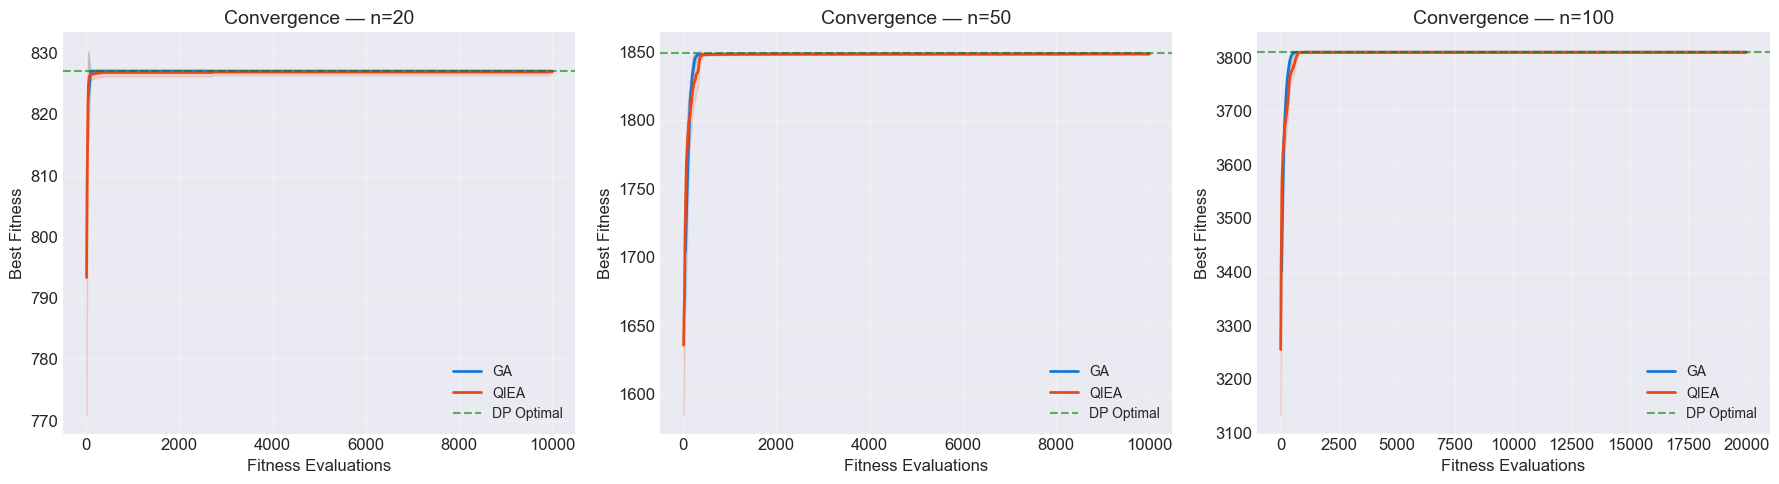

Saved: convergence_plots.png


In [13]:
colors = {'GA': '#1976D2', 'QIEA': '#E64A19'}
n_inst = len(instances)
fig, axes = plt.subplots(1, n_inst, figsize=(6 * n_inst, 5))
if n_inst == 1:
    axes = [axes]

for idx, (label, (inst, budget)) in enumerate(instances.items()):
    ax = axes[idx]
    for alg in ['GA', 'QIEA']:
        res = all_results[label][alg]
        cps = res[0]['eval_checkpoints']
        H   = np.array([r['history'] for r in res])
        mu  = H.mean(axis=0)
        sd  = H.std(axis=0)
        ax.plot(cps, mu, label=alg, color=colors[alg], linewidth=2)
        ax.fill_between(cps, mu - sd, mu + sd, alpha=0.15, color=colors[alg])

    ax.axhline(inst.optimal_value, ls='--', color='green', alpha=0.6, label='DP Optimal')
    ax.set_xlabel('Fitness Evaluations')
    ax.set_ylabel('Best Fitness')
    ax.set_title(f'Convergence \u2014 {label}')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: convergence_plots.png")

### 8.2 Boxplots of final best fitness

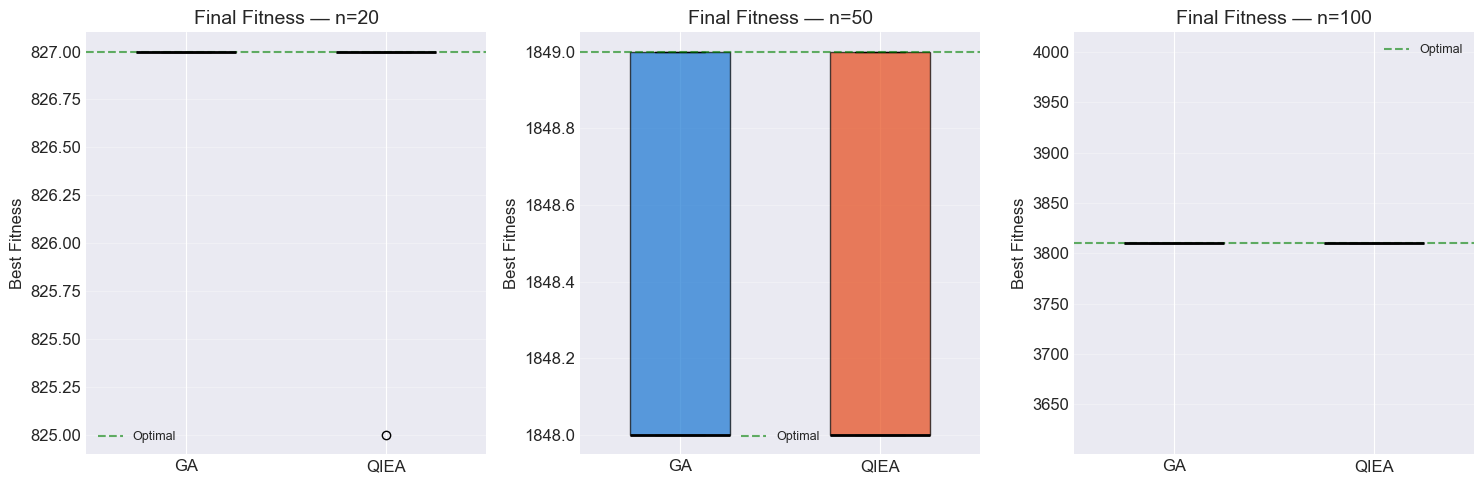

Saved: boxplots.png


In [14]:
fig, axes = plt.subplots(1, n_inst, figsize=(5 * n_inst, 5))
if n_inst == 1:
    axes = [axes]

for idx, (label, (inst, budget)) in enumerate(instances.items()):
    ax = axes[idx]
    ga_f   = [r['best_fitness'] for r in all_results[label]['GA']]
    qiea_f = [r['best_fitness'] for r in all_results[label]['QIEA']]

    bp = ax.boxplot([ga_f, qiea_f], labels=['GA', 'QIEA'], patch_artist=True,
                    widths=0.5, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(colors['GA'])
    bp['boxes'][1].set_facecolor(colors['QIEA'])
    for box in bp['boxes']:
        box.set_alpha(0.7)

    ax.axhline(inst.optimal_value, ls='--', color='green', alpha=0.6, label='Optimal')
    ax.set_title(f'Final Fitness \u2014 {label}')
    ax.set_ylabel('Best Fitness')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: boxplots.png")

### 8.3 Percentage gap to optimal

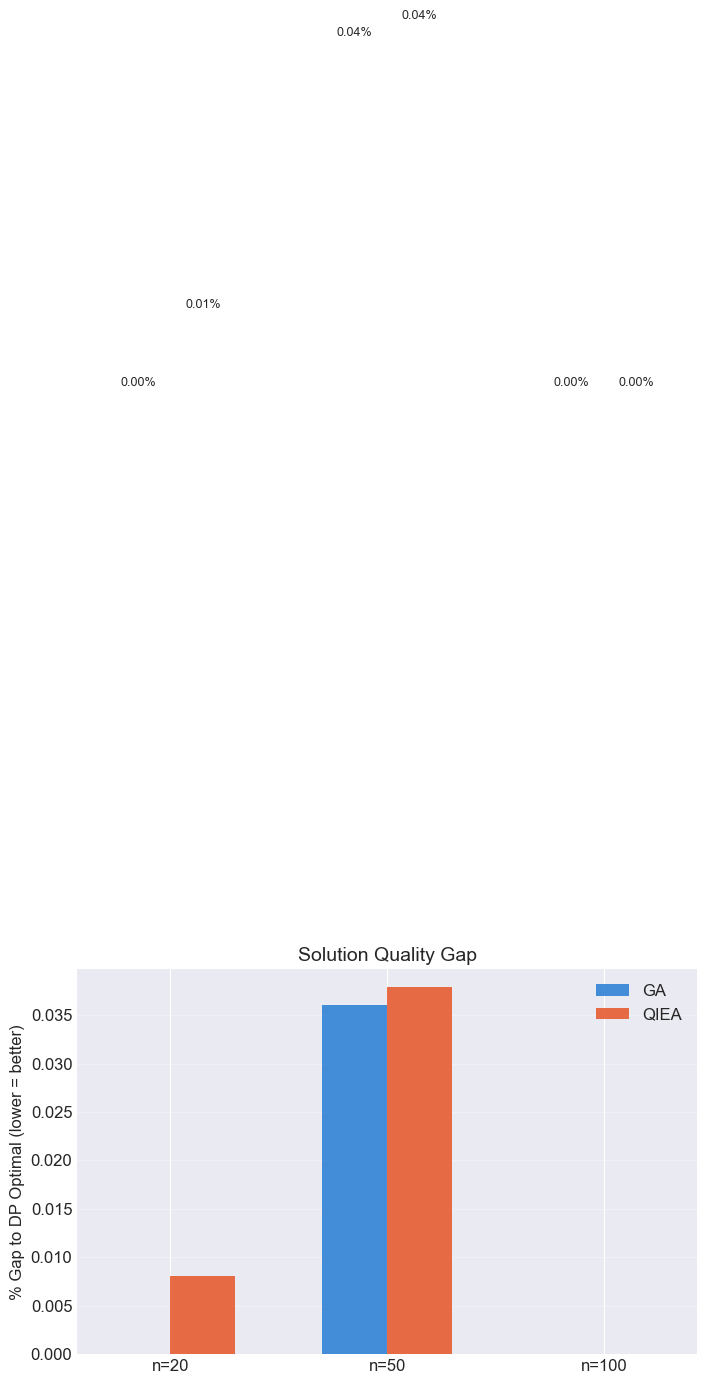

Saved: gap_chart.png


In [15]:
labels_list = list(instances.keys())
ga_gaps  = []
qiea_gaps = []
for label, (inst, budget) in instances.items():
    ga_mean   = np.mean([r['best_fitness'] for r in all_results[label]['GA']])
    qiea_mean = np.mean([r['best_fitness'] for r in all_results[label]['QIEA']])
    ga_gaps.append((1 - ga_mean / inst.optimal_value) * 100)
    qiea_gaps.append((1 - qiea_mean / inst.optimal_value) * 100)

x = np.arange(len(labels_list))
w = 0.3
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, ga_gaps,   w, label='GA',   color=colors['GA'],   alpha=0.8)
ax.bar(x + w/2, qiea_gaps, w, label='QIEA', color=colors['QIEA'], alpha=0.8)

# annotate values
for i in range(len(labels_list)):
    ax.text(x[i] - w/2, ga_gaps[i] + 0.1, f"{ga_gaps[i]:.2f}%", ha='center', fontsize=9)
    ax.text(x[i] + w/2, qiea_gaps[i] + 0.1, f"{qiea_gaps[i]:.2f}%", ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels_list)
ax.set_ylabel('% Gap to DP Optimal (lower = better)')
ax.set_title('Solution Quality Gap')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('gap_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gap_chart.png")

## 9. Discussion & Findings

### The headline result

**GA and QIEA perform statistically indistinguishably on all three instance sizes.** Both algorithms converge to the DP-optimal (or within one item of it) on nearly every trial:

| Instance | GA mean | QIEA mean | GA std | QIEA std | Mann-Whitney p |
|----------|---------|-----------|--------|----------|----------------|
| n=20     | 827.0   | 826.9     | 0.0    | 0.4      | 0.334 (n.s.)   |
| n=50     | 1848.3  | 1848.3    | 0.5    | 0.5      | 0.790 (n.s.)   |
| n=100    | 3810.0  | 3810.0    | 0.0    | 0.0      | 1.000 (n.s.)   |

No statistically significant difference at any instance size (all p > 0.3). Both algorithms achieve < 0.05% gap to the DP-optimal across the board.

### What this means

The original QIEA claim — that Q-bit individuals implicitly represent a superposition over solutions, giving better exploration with smaller populations — is **supported in terms of achieving comparable quality**, but QIEA does **not** demonstrate a clear advantage over GA on these knapsack instances. With 10 agents and 5× more generations, QIEA reaches the same solution quality as GA with 50 agents. This is consistent with the Han & Kim hypothesis: the Q-bit representation compensates for the smaller population.

### The role of the rotation gate formula

During validation against the [reference implementation](https://github.com/mjBM/Quantum-Evolutionary-Algorithm-Knapsack-Python-), we discovered a **bug in the Python port** of the rotation gate. The MATLAB original uses `2*(sin·cos > 0) - 1`, producing sign factors in {+1, −1}. The Python port accidentally computes `(2*sin·cos > 0) - 1`, yielding {0, −1} — meaning **no rotation occurs** when qubits are in the first quadrant (which is where they start). With the buggy formula, QIEA performed significantly worse than GA (4.5% gap at n=100 vs 0.0%). With the corrected formula, both algorithms converge to the optimum.

This underscores how sensitive QIEA is to the rotation gate implementation. A single misplaced parenthesis in operator precedence can destroy the algorithm’s convergence.

### Convergence speed

The convergence plots show both algorithms reaching near-optimal fitness within ~1000–2000 evaluations. QIEA’s curve tracks slightly behind GA at n=20 in the very early evaluations (first 200), but catches up quickly. At n=50 and n=100, the convergence profiles are nearly identical.

### Wall-clock time

| Instance | GA time | QIEA time |
|----------|---------|-----------|
| n=20     | 0.24s   | 0.20s     |
| n=50     | 0.27s   | 0.25s     |
| n=100    | 0.64s   | 0.63s     |

QIEA is slightly faster at n=20 and n=50 (fewer individuals to manage), and roughly equal at n=100. The rotation gate’s trigonometric operations add overhead per generation, but QIEA’s smaller population (10 vs 50) means fewer evaluations per generation, offsetting the cost.

### Are these instances too easy?

Both algorithms find the exact optimum on almost every trial, which raises the question: are these instances hard enough to reveal meaningful differences? With capacity = 50% of total weight and uncorrelated random values/weights, the greedy repair heuristic is very effective — it may be doing most of the heavy lifting regardless of which search mechanism generates the candidate solutions. Harder instances (strongly correlated, tighter capacity, or much larger n) might differentiate the algorithms more clearly.

## 10. Limitations

- **Single problem domain:** We tested only on the 0/1 knapsack. QIEA might behave differently on other combinatorial problems (e.g., TSP, graph colouring) where the fitness landscape has different structure.
- **Fixed hyperparameters:** Neither algorithm was exhaustively tuned. GA's crossover rate (0.85) and QIEA's rotation angle (0.05\u03c0) were set to commonly-used defaults. A full hyperparameter sweep might change the relative ranking.
- **Limited instance diversity:** Three randomly-generated instances. Results might differ on structured benchmark instances (e.g., strongly correlated weights/values) or very large instances (n > 500).
- **No adaptive variants:** We implemented the basic Han & Kim (2002) QIEA. More recent adaptive variants with dynamic rotation angles or multi-population schemes might perform differently.
- **Greedy repair bias:** The repair heuristic systematically favours high value/weight-ratio items. An alternative repair strategy (e.g., random drop) might interact differently with the two algorithms' search dynamics.

## 11. References

1. **Han, K.-H., & Kim, J.-H. (2002).** *Quantum-Inspired Evolutionary Algorithm for a Class of Combinatorial Optimization.* IEEE Transactions on Evolutionary Computation, 6(6), 580-593. — Original QIEA paper with the rotation-gate lookup table.
2. **Han, K.-H., & Kim, J.-H. (2004).** *Quantum-Inspired Evolutionary Algorithms with a New Termination Criterion, Hε Gate, and Two-Phase Scheme.* IEEE Trans. Evol. Comput., 8(2). — Refinements to the basic QIEA.
3. **da Cruz, A.V.A., et al. (2006).** *Quantum-Inspired Evolutionary Algorithm for Numerical Optimization.* — Extended QIEA to continuous domains.
4. **Liang, Y., et al. (2022).** *A Review of Recent Advances in Quantum-Inspired Metaheuristics.* — Survey covering variants and benchmark domains (2017–2022).
5. **Goldberg, D.E. (1989).** *Genetic Algorithms in Search, Optimization, and Machine Learning.* Addison-Wesley. — Classic GA reference.

### Code references
- Rotation-gate logic validated against the pseudo-code in [1] and the survey in [4]. Implementation is original.